In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pickle

from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_absolute_error, r2_score


In [2]:
df = pd.read_csv("Electric_Vehicle_Population_Data.csv")

print(df.head())
df.info()

   VIN (1-10)    County               City State  Postal Code  Model Year  \
0  1N4AZ0CP6D      King           Kirkland    WA      98034.0        2013   
1  5YJ3E1EC8L    Kitsap  Bainbridge Island    WA      98110.0        2020   
2  5YJ3E1EBXJ      King            Seattle    WA      98144.0        2018   
3  ZFAFFAC45R  Thurston               Yelm    WA      98597.0        2024   
4  5YJYGDEE3L      King               Kent    WA      98030.0        2020   

     Make    Model           Electric Vehicle Type  \
0  NISSAN     LEAF  Battery Electric Vehicle (BEV)   
1   TESLA  MODEL 3  Battery Electric Vehicle (BEV)   
2   TESLA  MODEL 3  Battery Electric Vehicle (BEV)   
3    FIAT     500E  Battery Electric Vehicle (BEV)   
4   TESLA  MODEL Y  Battery Electric Vehicle (BEV)   

   Clean Alternative Fuel Vehicle (CAFV) Eligibility  Electric Range  \
0            Clean Alternative Fuel Vehicle Eligible            75.0   
1            Clean Alternative Fuel Vehicle Eligible           308.0

In [3]:
df = df.dropna()
df = df.drop_duplicates()
df = df[df['Electric Range'] > 0]

print("Shape:", df.shape)

Shape: (100992, 16)


In [4]:
features = [
    'Make',
    'Model Year',
    'Electric Vehicle Type',
    'County',
    'Clean Alternative Fuel Vehicle (CAFV) Eligibility'
]

target = 'Electric Range'

X = df[features].copy()
y = df[target]

In [5]:
encoders = {}

for col in X.select_dtypes(include='object').columns:
    le = LabelEncoder()
    X[col] = le.fit_transform(X[col])
    encoders[col] = le

C:\Users\iampr\AppData\Local\Temp\ipykernel_19084\4020813428.py:3: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  for col in X.select_dtypes(include='object').columns:


In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [7]:
models = {
    "Linear Regression": LinearRegression(),
    "Decision Tree": DecisionTreeRegressor(),
    "Random Forest": RandomForestRegressor()
}

print("Model Comparison:\n")

for name, model in models.items():
    model.fit(X_train, y_train)
    pred = model.predict(X_test)
    print(f"{name} R2 Score:", r2_score(y_test, pred))

Model Comparison:

Linear Regression R2 Score: 0.7739630511983676
Decision Tree R2 Score: 0.991775275975062
Random Forest R2 Score: 0.9918509429139699


In [8]:
rf = RandomForestRegressor()

cv_scores = cross_val_score(rf, X, y, cv=5)

print("\nCross Validation Scores:", cv_scores)
print("Average CV Score:", cv_scores.mean())


Cross Validation Scores: [0.99138969 0.99164279 0.99178786 0.99123756 0.99155247]
Average CV Score: 0.9915220746800262


In [9]:
param_grid = {
    'n_estimators': [50, 100],
    'max_depth': [5, 10, None]
}

grid = GridSearchCV(RandomForestRegressor(), param_grid, cv=3)
grid.fit(X_train, y_train)

best_model = grid.best_estimator_

print("Best Parameters:", grid.best_params_)

Best Parameters: {'max_depth': 10, 'n_estimators': 100}


In [10]:
pred = best_model.predict(X_test)

print("\nFinal Model Performance:")
print("MAE:", mean_absolute_error(y_test, pred))
print("R2 Score:", r2_score(y_test, pred))


Final Model Performance:
MAE: 3.489569328786697
R2 Score: 0.9918436672810477


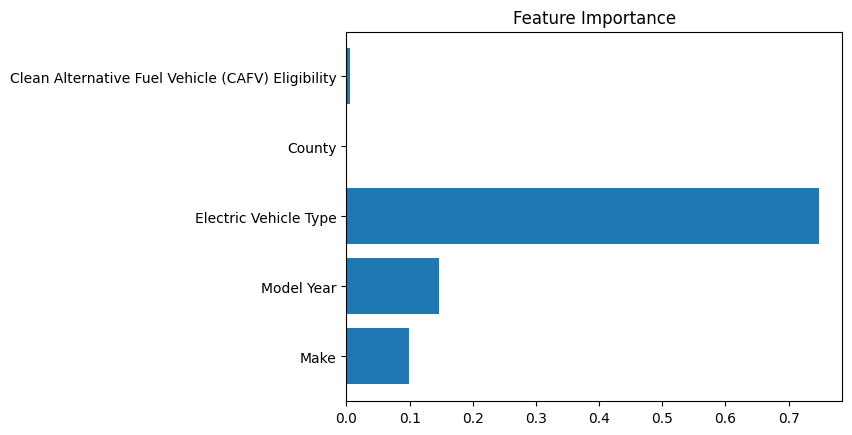

In [11]:
importance = best_model.feature_importances_

plt.figure()
plt.barh(X.columns, importance)
plt.title("Feature Importance")
plt.show()

In [12]:
with open("model.pkl", "wb") as f:
    pickle.dump(best_model, f)

with open("encoders.pkl", "wb") as f:
    pickle.dump(encoders, f)

print("Model and encoders saved!")

Model and encoders saved!
